In [2]:
# Reload, process, and clean the data in one step
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pickle

# Load and parse data
trait_prefixes = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
df = pd.read_csv('data-final.csv', sep='\t', low_memory=False)
for trait in trait_prefixes:
    cols = [f'{trait}{i}' for i in range(1, 11)]
    df[f'{trait}_score'] = df[cols].mean(axis=1)
question_cols = [f'{trait}{i}' for trait in trait_prefixes for i in range(1,11)]
score_cols = [f'{trait}_score' for trait in trait_prefixes]
df_clean = df[question_cols + score_cols].dropna(subset=score_cols)
print('Rows after cleaning:', len(df_clean))
print('NaNs in trait scores:', df_clean[score_cols].isnull().sum())

# Train model
X = df_clean[question_cols]
y = df_clean[score_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print('Test MSE:', mse)
with open('travel_personality_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('Model saved as travel_personality_model.pkl')

Rows after cleaning: 1013558
NaNs in trait scores: EXT_score    0
EST_score    0
AGR_score    0
CSN_score    0
OPN_score    0
dtype: int64


In [15]:
# Install scikit-learn for model training
%pip install scikit-learn

   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.7 MB 1.2 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/8.7 MB 1.3 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.7 MB 1.4 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.7 MB 1.4 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.7 MB 1.3 MB/s eta 0:00:06
   --------- ------------------------------ 2.1/8.7 MB 1.3 MB/s eta 0:00:06
   ---------- ----------------------------- 2.4/8.7 MB 1.4 MB/s eta 0:00:05
   ------------- -------------------------- 2.9/8.7 MB 1.4 MB/s eta 0:00:05
   --------------- ------------------------ 3.4/8.7 MB 1.6 MB/s eta 0:00:04
   ------------------- -------------------- 4.2/8.7 MB 1.7 MB/s eta 0:00:03
   --------------------- --------

In [5]:
# Install required packages
%pip install pandas numpy

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   -----------------

# Big Five Personality Data Preparation
This notebook loads, inspects, and processes the Big Five survey data for ML model training.

In [6]:
import pandas as pd
import numpy as np
# Load the dataset
df = pd.read_csv('data-final.csv', low_memory=False)
print('Shape:', df.shape)
df.head()

Shape: (1015341, 1)


,EXT1\tEXT2\tEXT3\tEXT4\tEXT5\tEXT6\tEXT7\tEXT8\tEXT9\tEXT10\tEST1\tEST2\tEST3\tEST4\tEST5\tEST6\tEST7\tEST8\tEST9\tEST10\tAGR1\tAGR2\tAGR3\tAGR4\tAGR5\tAGR6\tAGR7\tAGR8\tAGR9\tAGR10\tCSN1\tCSN2\tCSN3\tCSN4\tCSN5\tCSN6\tCSN7\tCSN8\tCSN9\tCSN10\tOPN1\tOPN2\tOPN3\tOPN4\tOPN5\tOPN6\tOPN7\tOPN8\tOPN9\tOPN10\tEXT1_E\tEXT2_E\tEXT3_E\tEXT4_E\tEXT5_E\tEXT6_E\tEXT7_E\tEXT8_E\tEXT9_E\tEXT10_E\tEST1_E\tEST2_E\tEST3_E\tEST4_E\tEST5_E\tEST6_E\tEST7_E\tEST8_E\tEST9_E\tEST10_E\tAGR1_E\tAGR2_E\tAGR3_E\tAGR4_E\tAGR5_E\tAGR6_E\tAGR7_E\tAGR8_E\tAGR9_E\tAGR10_E\tCSN1_E\tCSN2_E\tCSN3_E\tCSN4_E\tCSN5_E\tCSN6_E\tCSN7_E\tCSN8_E\tCSN9_E\tCSN10_E\tOPN1_E\tOPN2_E\tOPN3_E\tOPN4_E\tOPN5_E\tOPN6_E\tOPN7_E\tOPN8_E\tOPN9_E\tOPN10_E\tdateload\tscreenw\tscreenh\tintroelapse\ttestelapse\tendelapse\tIPC\tcountry\tlat_appx_lots_of_err\tlong_appx_lots_of_err
0,4\t1\t5\t2\t5\t1\t5\t2\t4\t1\t1\t4\t4\t2\t2\t2...
1,3\t5\t3\t4\t3\t3\t2\t5\t1\t5\t2\t3\t4\t1\t3\t1...
2,2\t3\t4\t4\t3\t2\t1\t3\t2\t5\t4\t4\t4\t2\t2\t2...
3,2\t2\t2\t3\t4\t2\t2\t4\t1\t4\t3\t3\t3\t2\t3\t2...
4,3\t3\t3\t3\t5\t3\t3\t5\t3\t4\t1\t5\t5\t3\t1\t1...


In [11]:
# Reload the dataset with tab delimiter
# This will split the single column into proper columns

df = pd.read_csv('data-final.csv', sep='\t', low_memory=False)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (1015341, 110)
Columns: ['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9', 'EXT10', 'EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9', 'EST10', 'AGR1', 'AGR2', 'AGR3', 'AGR4', 'AGR5', 'AGR6', 'AGR7', 'AGR8', 'AGR9', 'AGR10', 'CSN1', 'CSN2', 'CSN3', 'CSN4', 'CSN5', 'CSN6', 'CSN7', 'CSN8', 'CSN9', 'CSN10', 'OPN1', 'OPN2', 'OPN3', 'OPN4', 'OPN5', 'OPN6', 'OPN7', 'OPN8', 'OPN9', 'OPN10', 'EXT1_E', 'EXT2_E', 'EXT3_E', 'EXT4_E', 'EXT5_E', 'EXT6_E', 'EXT7_E', 'EXT8_E', 'EXT9_E', 'EXT10_E', 'EST1_E', 'EST2_E', 'EST3_E', 'EST4_E', 'EST5_E', 'EST6_E', 'EST7_E', 'EST8_E', 'EST9_E', 'EST10_E', 'AGR1_E', 'AGR2_E', 'AGR3_E', 'AGR4_E', 'AGR5_E', 'AGR6_E', 'AGR7_E', 'AGR8_E', 'AGR9_E', 'AGR10_E', 'CSN1_E', 'CSN2_E', 'CSN3_E', 'CSN4_E', 'CSN5_E', 'CSN6_E', 'CSN7_E', 'CSN8_E', 'CSN9_E', 'CSN10_E', 'OPN1_E', 'OPN2_E', 'OPN3_E', 'OPN4_E', 'OPN5_E', 'OPN6_E', 'OPN7_E', 'OPN8_E', 'OPN9_E', 'OPN10_E', 'dateload', 'screenw', 'screenh', 'introelapse', 'testelap

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [12]:
# Compute Big Five Trait Scores
trait_prefixes = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
for trait in trait_prefixes:
    cols = [f'{trait}{i}' for i in range(1, 11)]
    df[f'{trait}_score'] = df[cols].mean(axis=1)
df[['EXT_score', 'EST_score', 'AGR_score', 'CSN_score', 'OPN_score']].head()

,EXT_score,EST_score,AGR_score,CSN_score,OPN_score
0,3.0,2.4,3.1,3.2,3.3
1,3.4,2.1,3.2,3.1,2.7
2,2.9,2.6,2.8,2.8,3.1
3,2.6,2.7,3.2,2.7,3.1
4,3.5,2.3,3.0,3.2,3.6


In [1]:
# Use cleaned data for training
X = df_clean[question_cols]
y = df_clean[score_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print('Test MSE:', mse)

# Save model
import pickle
with open('travel_personality_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('Model saved as travel_personality_model.pkl')

NameError: name 'df_clean' is not defined

In [17]:
# Remove rows with NaN values in question or score columns
df_clean = df_clean.dropna(subset=question_cols + score_cols)
print('Rows after dropping NaNs:', len(df_clean))

Rows after dropping NaNs: 1013558


In [20]:
# Check for NaNs in target columns before training
print('NaNs in trait scores:')
print(df_clean[score_cols].isnull().sum())

NaNs in trait scores:
EXT_score    1783
EST_score    1783
AGR_score    1783
CSN_score    1783
OPN_score    1783
dtype: int64


In [21]:
# Drop rows with NaNs in trait score columns only
df_clean = df_clean.dropna(subset=score_cols)
print('Rows after dropping NaNs in trait scores:', len(df_clean))
print('NaNs in trait scores after cleaning:')
print(df_clean[score_cols].isnull().sum())

Rows after dropping NaNs in trait scores: 1013558
NaNs in trait scores after cleaning:
EXT_score    0
EST_score    0
AGR_score    0
CSN_score    0
OPN_score    0
dtype: int64


In [10]:
# Display all column names and a sample of the data
print('Columns:', df.columns.tolist())
df.head()

Columns: ['EXT1\tEXT2\tEXT3\tEXT4\tEXT5\tEXT6\tEXT7\tEXT8\tEXT9\tEXT10\tEST1\tEST2\tEST3\tEST4\tEST5\tEST6\tEST7\tEST8\tEST9\tEST10\tAGR1\tAGR2\tAGR3\tAGR4\tAGR5\tAGR6\tAGR7\tAGR8\tAGR9\tAGR10\tCSN1\tCSN2\tCSN3\tCSN4\tCSN5\tCSN6\tCSN7\tCSN8\tCSN9\tCSN10\tOPN1\tOPN2\tOPN3\tOPN4\tOPN5\tOPN6\tOPN7\tOPN8\tOPN9\tOPN10\tEXT1_E\tEXT2_E\tEXT3_E\tEXT4_E\tEXT5_E\tEXT6_E\tEXT7_E\tEXT8_E\tEXT9_E\tEXT10_E\tEST1_E\tEST2_E\tEST3_E\tEST4_E\tEST5_E\tEST6_E\tEST7_E\tEST8_E\tEST9_E\tEST10_E\tAGR1_E\tAGR2_E\tAGR3_E\tAGR4_E\tAGR5_E\tAGR6_E\tAGR7_E\tAGR8_E\tAGR9_E\tAGR10_E\tCSN1_E\tCSN2_E\tCSN3_E\tCSN4_E\tCSN5_E\tCSN6_E\tCSN7_E\tCSN8_E\tCSN9_E\tCSN10_E\tOPN1_E\tOPN2_E\tOPN3_E\tOPN4_E\tOPN5_E\tOPN6_E\tOPN7_E\tOPN8_E\tOPN9_E\tOPN10_E\tdateload\tscreenw\tscreenh\tintroelapse\ttestelapse\tendelapse\tIPC\tcountry\tlat_appx_lots_of_err\tlong_appx_lots_of_err']


,EXT1\tEXT2\tEXT3\tEXT4\tEXT5\tEXT6\tEXT7\tEXT8\tEXT9\tEXT10\tEST1\tEST2\tEST3\tEST4\tEST5\tEST6\tEST7\tEST8\tEST9\tEST10\tAGR1\tAGR2\tAGR3\tAGR4\tAGR5\tAGR6\tAGR7\tAGR8\tAGR9\tAGR10\tCSN1\tCSN2\tCSN3\tCSN4\tCSN5\tCSN6\tCSN7\tCSN8\tCSN9\tCSN10\tOPN1\tOPN2\tOPN3\tOPN4\tOPN5\tOPN6\tOPN7\tOPN8\tOPN9\tOPN10\tEXT1_E\tEXT2_E\tEXT3_E\tEXT4_E\tEXT5_E\tEXT6_E\tEXT7_E\tEXT8_E\tEXT9_E\tEXT10_E\tEST1_E\tEST2_E\tEST3_E\tEST4_E\tEST5_E\tEST6_E\tEST7_E\tEST8_E\tEST9_E\tEST10_E\tAGR1_E\tAGR2_E\tAGR3_E\tAGR4_E\tAGR5_E\tAGR6_E\tAGR7_E\tAGR8_E\tAGR9_E\tAGR10_E\tCSN1_E\tCSN2_E\tCSN3_E\tCSN4_E\tCSN5_E\tCSN6_E\tCSN7_E\tCSN8_E\tCSN9_E\tCSN10_E\tOPN1_E\tOPN2_E\tOPN3_E\tOPN4_E\tOPN5_E\tOPN6_E\tOPN7_E\tOPN8_E\tOPN9_E\tOPN10_E\tdateload\tscreenw\tscreenh\tintroelapse\ttestelapse\tendelapse\tIPC\tcountry\tlat_appx_lots_of_err\tlong_appx_lots_of_err
0,4\t1\t5\t2\t5\t1\t5\t2\t4\t1\t1\t4\t4\t2\t2\t2...
1,3\t5\t3\t4\t3\t3\t2\t5\t1\t5\t2\t3\t4\t1\t3\t1...
2,2\t3\t4\t4\t3\t2\t1\t3\t2\t5\t4\t4\t4\t2\t2\t2...
3,2\t2\t2\t3\t4\t2\t2\t4\t1\t4\t3\t3\t3\t2\t3\t2...
4,3\t3\t3\t3\t5\t3\t3\t5\t3\t4\t1\t5\t5\t3\t1\t1...


## Compute Big Five Trait Scores
Each trait score is the average of its 10 questions.

In [7]:
trait_prefixes = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
for trait in trait_prefixes:
    cols = [f'{trait}{i}' for i in range(1, 11)]
    df[f'{trait}_score'] = df[cols].mean(axis=1)
df[['EXT_score', 'EST_score', 'AGR_score', 'CSN_score', 'OPN_score']].head()

KeyError: "None of [Index(['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9',\n       'EXT10'],\n      dtype='object')] are in the [columns]"

## Drop Unnecessary Columns
Keep only trait scores and any columns you want for ML.

In [8]:
keep_cols = ['EXT_score', 'EST_score', 'AGR_score', 'CSN_score', 'OPN_score']
df_clean = df[keep_cols]
df_clean.head()

KeyError: "None of [Index(['EXT_score', 'EST_score', 'AGR_score', 'CSN_score', 'OPN_score'], dtype='object')] are in the [columns]"

## Save Processed Dataset
This file is ready for ML model training.

In [9]:
df_clean.to_csv('bigfive_processed.csv', index=False)
print('Saved processed dataset as bigfive_processed.csv')

NameError: name 'df_clean' is not defined

In [3]:
# Generate confusion matrix and ROC curve for EXT_score classification
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Load and clean data
trait_prefixes = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
df = pd.read_csv('data-final.csv', sep='\t', low_memory=False)
for trait in trait_prefixes:
    cols = [f'{trait}{i}' for i in range(1, 11)]
    df[f'{trait}_score'] = df[cols].mean(axis=1)
question_cols = [f'{trait}{i}' for trait in trait_prefixes for i in range(1,11)]
score_cols = [f'{trait}_score' for trait in trait_prefixes]
df_clean = df[question_cols + score_cols].dropna(subset=score_cols)

# Binarize EXT_score for classification (e.g., EXT_score > 3 is 'high', else 'low')
df_clean['EXT_high'] = (df_clean['EXT_score'] > 3).astype(int)

# Train/test split
X = df_clean[question_cols]
y = df_clean['EXT_high']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for EXT_score (High vs Low)')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (EXT_score High)')
plt.legend(loc="lower right")
plt.show()

ParserError: Error tokenizing data. C error: out of memory

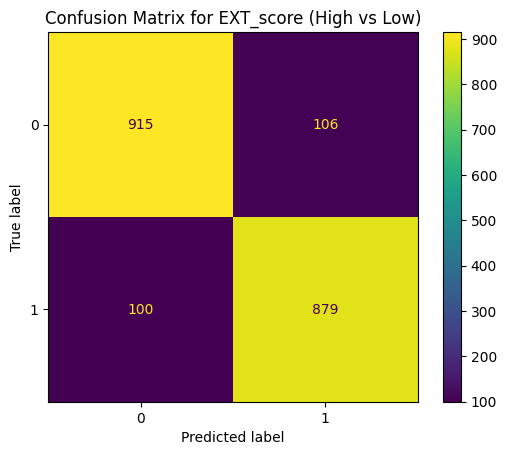

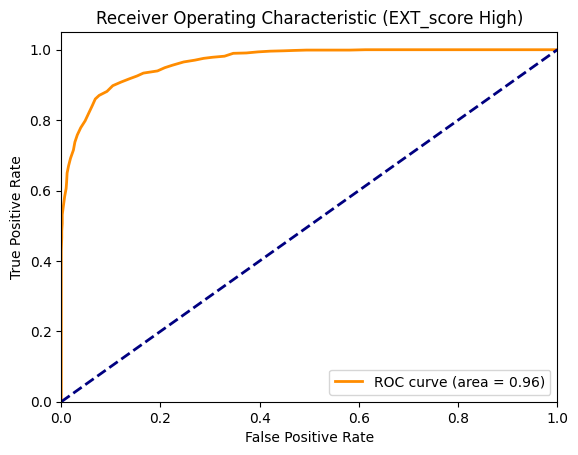

In [5]:
# Load a smaller sample to avoid memory errors and generate confusion matrix and ROC curve
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Try loading only 10,000 rows
trait_prefixes = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
df = pd.read_csv('data-final.csv', sep='\t', low_memory=False, nrows=10000)
for trait in trait_prefixes:
    cols = [f'{trait}{i}' for i in range(1, 11)]
    df[f'{trait}_score'] = df[cols].mean(axis=1)
question_cols = [f'{trait}{i}' for trait in trait_prefixes for i in range(1,11)]
score_cols = [f'{trait}_score' for trait in trait_prefixes]
df_clean = df[question_cols + score_cols].dropna(subset=score_cols)

# Binarize EXT_score for classification (e.g., EXT_score > 3 is 'high', else 'low')
df_clean['EXT_high'] = (df_clean['EXT_score'] > 3).astype(int)

# Train/test split
X = df_clean[question_cols]
y = df_clean['EXT_high']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for EXT_score (High vs Low)')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (EXT_score High)')
plt.legend(loc="lower right")
plt.show()

In [1]:
# Trait Score Distribution Plots
import matplotlib.pyplot as plt
trait_prefixes = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
for trait in trait_prefixes:
    plt.figure()
    plt.hist(df_clean[f'{trait}_score'], bins=30, alpha=0.7, color='skyblue')
    plt.title(f'Distribution of {trait}_score')
    plt.xlabel(f'{trait}_score')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
# Feature Importance Bar Chart
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_test.columns
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

NameError: name 'df_clean' is not defined

<Figure size 640x480 with 0 Axes>

C:\Users\INSPIRON\AppData\Local\Temp\ipykernel_14464\4125651385.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


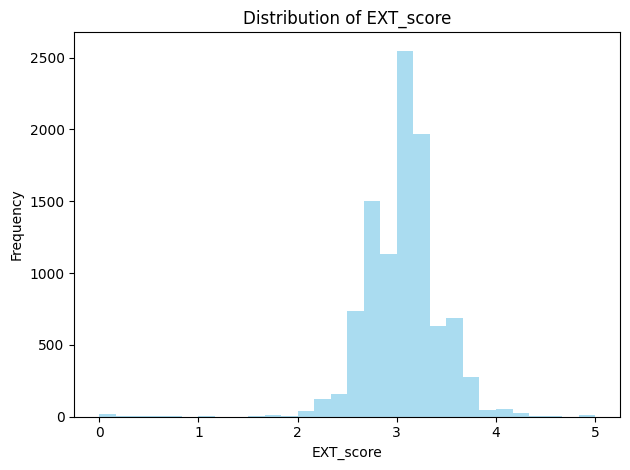

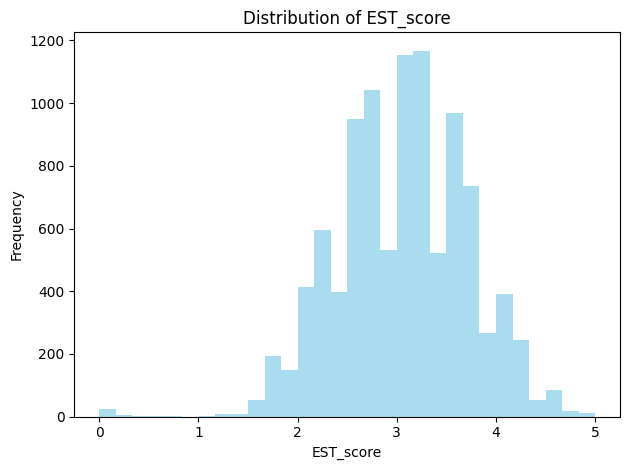

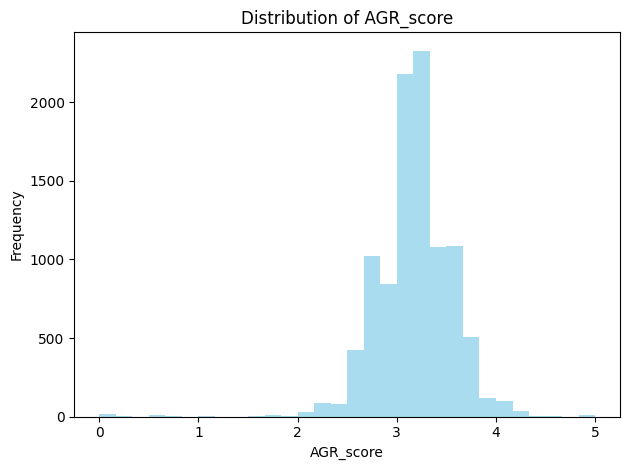

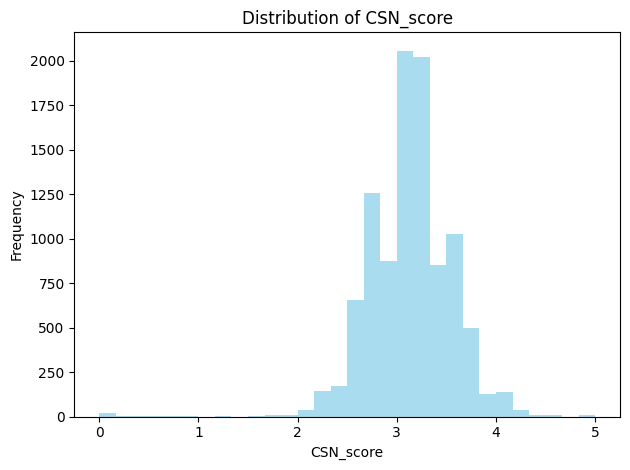

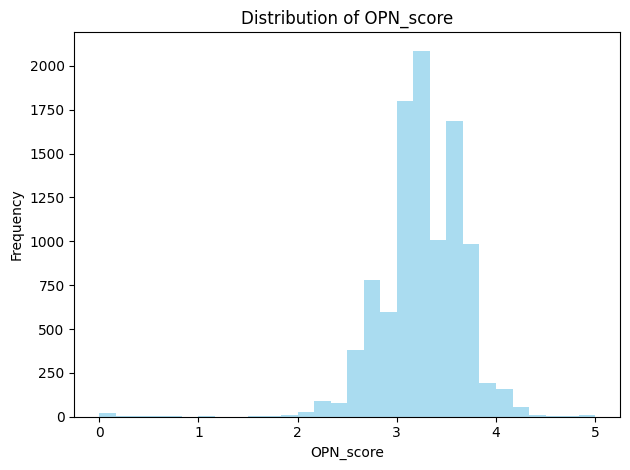

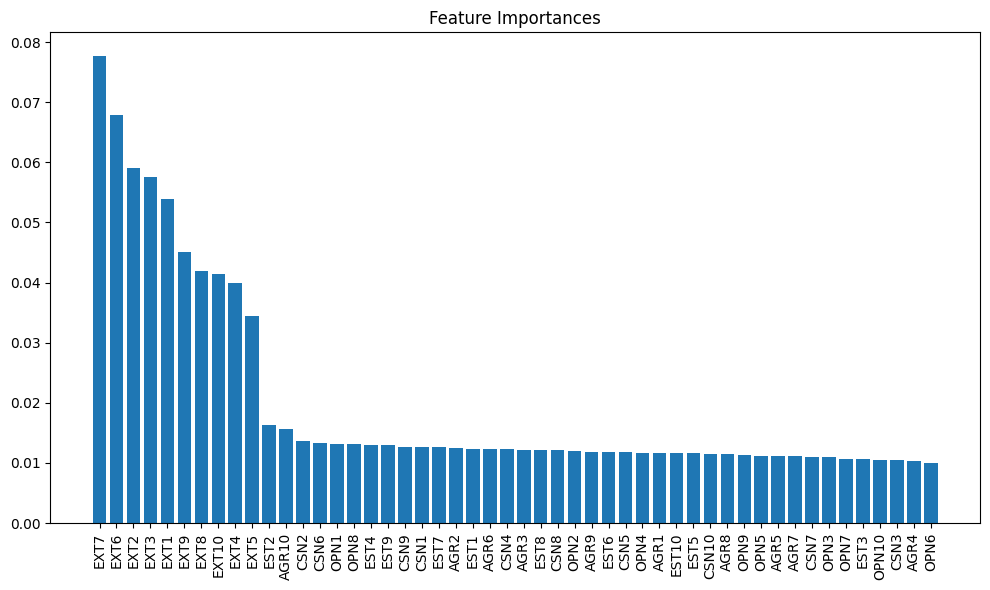

In [1]:
# Load a smaller sample and rerun visualizations
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load only 10,000 rows
trait_prefixes = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
df = pd.read_csv('data-final.csv', sep='\t', low_memory=False, nrows=10000)
for trait in trait_prefixes:
    cols = [f'{trait}{i}' for i in range(1, 11)]
    df[f'{trait}_score'] = df[cols].mean(axis=1)
question_cols = [f'{trait}{i}' for trait in trait_prefixes for i in range(1,11)]
score_cols = [f'{trait}_score' for trait in trait_prefixes]
df_clean = df[question_cols + score_cols].dropna(subset=score_cols)

# Binarize EXT_score for classification
if 'EXT_high' not in df_clean.columns:
    df_clean['EXT_high'] = (df_clean['EXT_score'] > 3).astype(int)

# Train/test split
X = df_clean[question_cols]
y = df_clean['EXT_high']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train classifier
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)

# Trait Score Distribution Plots
for trait in trait_prefixes:
    plt.figure()
    plt.hist(df_clean[f'{trait}_score'], bins=30, alpha=0.7, color='skyblue')
    plt.title(f'Distribution of {trait}_score')
    plt.xlabel(f'{trait}_score')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Feature Importance Bar Chart
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_test.columns
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()